In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
iris = load_iris()
X = iris.data          # features
y = iris.target        # true labels (only for evaluation)
feature_names = iris.feature_names


In [12]:
df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)



In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
print(X.shape)


(150, 4)


In [15]:
print(y.shape)

(150,)


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
print(X_scaled.shape)

(150, 4)


In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [6]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster labels:", labels[:10])
print("Centroids:\n", centroids)


Cluster labels: [1 1 1 1 1 1 1 1 1 1]
Centroids:
 [[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


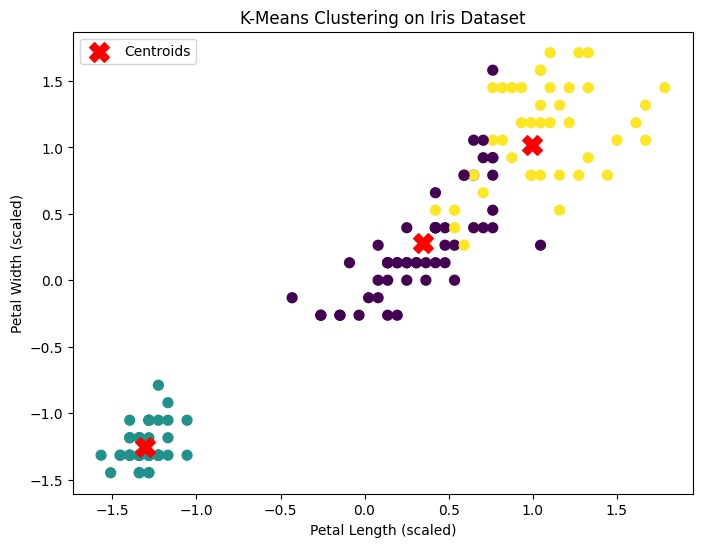

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=labels,
    cmap='viridis',
    s=50
)

plt.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.show()


In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, labels)
print(cm)


[[ 0 50  0]
 [39  0 11]
 [14  0 36]]


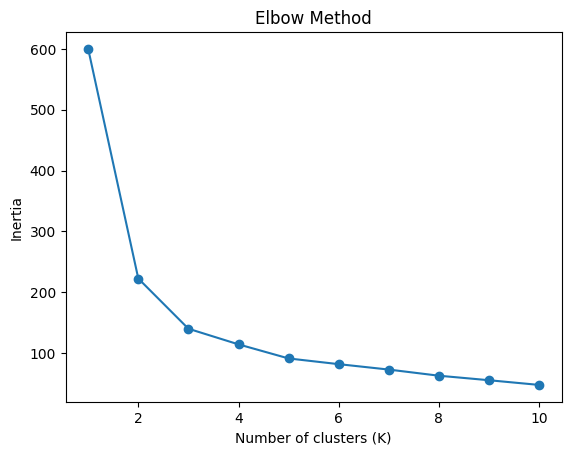

In [9]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


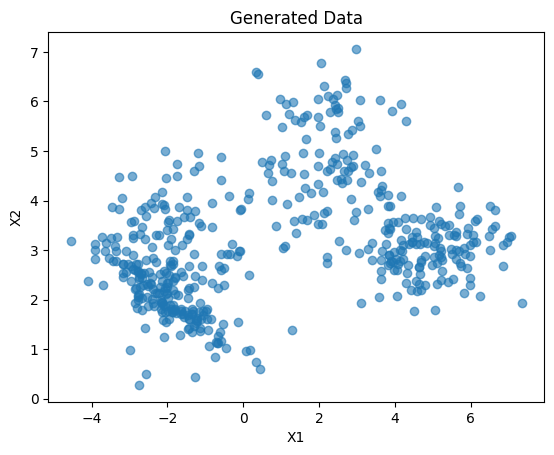

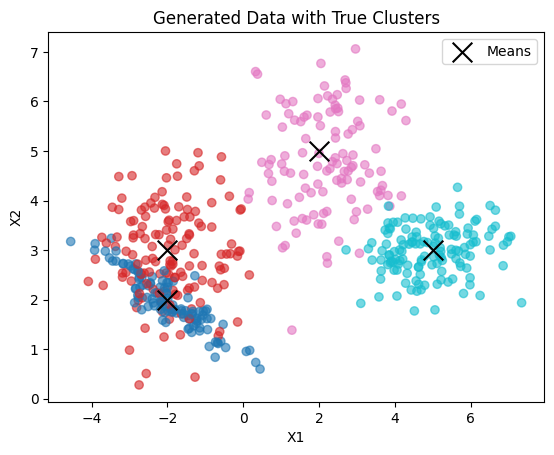

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans

# Parameters
n = 500 # Number of data points
d = 2 # Data dimensionality
K = 4 # Number of Gaussian components

# Mixing proportions
Pi = np.ones(K) / K

# Mean vectors
Mu = np.array([[-2, 2], [-2, 3], [2, 5], [5, 3]])

# Covariance matrices
Sigma = np.array([np.eye(d) for _ in range(K)])
Sigma[0] = np.array([[1, -0.5], [-0.5, 0.3]])
Sigma[K-1] = np.array([[1, 0], [0, 0.3]])

# Generate data
X = np.zeros((n, d))
z = np.zeros(n, dtype=int)

for i in range(n):
    zi = np.random.choice(K, p=Pi)
    z[i] = zi
    X[i, :] = np.random.multivariate_normal(Mu[zi], Sigma[zi])

# Plot generated data
plt.figure()
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title("Generated Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

# Plot (true) means and clusters
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=z, cmap='tab10', alpha=0.6)
plt.scatter(Mu[:, 0], Mu[:, 1], c='k', marker='x', s=200, label='Means')
plt.legend()
plt.title("Generated Data with True Clusters")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()